<a href="https://colab.research.google.com/github/Faisaleka21/Machine_Learning/blob/main/FCM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
#inisialisasi library tambahan
!pip install scikit-fuzzy

In [11]:
#Gunakan dataset Mall Customers
import pandas as pd
url = "https://raw.githubusercontent.com/febbisena/DataMining/main/mall_customers.csv"
df = pd.read_csv(url)
df.head()

,customer_id,gender,age,annual_income,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [12]:
#melakukan prepocessing
from sklearn.preprocessing import StandardScaler
X = df.iloc[:, 3:].values # Ambil fitur Annual Income dan Spending Score
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

In [13]:
#implementasi FCM
import numpy as np
import skfuzzy as fuzz
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(X_scaled.T, c=5, m=2, error=0.01, maxiter=1000, init=None)
df['Cluster'] = np.argmax(u, axis=0) + 1

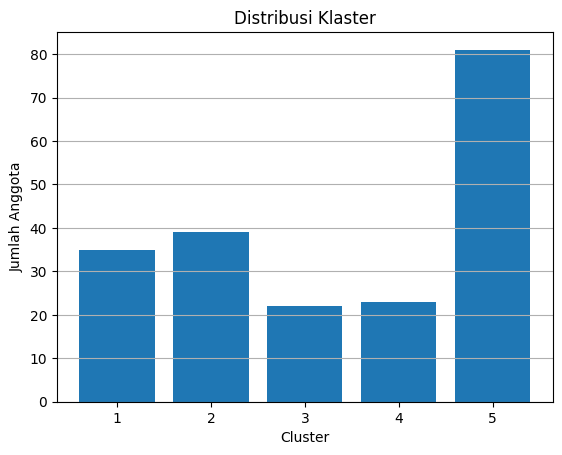

In [14]:
#visualisasi dan analisis klaster
#melakukan distribusi anggota setiap klaster
import matplotlib.pyplot as plt
cluster_counts = df['Cluster'].value_counts().sort_index()
plt.bar(cluster_counts.index, cluster_counts.values)
plt.xlabel('Cluster')
plt.ylabel('Jumlah Anggota')
plt.title('Distribusi Klaster')
plt.grid(axis='y')
plt.show()

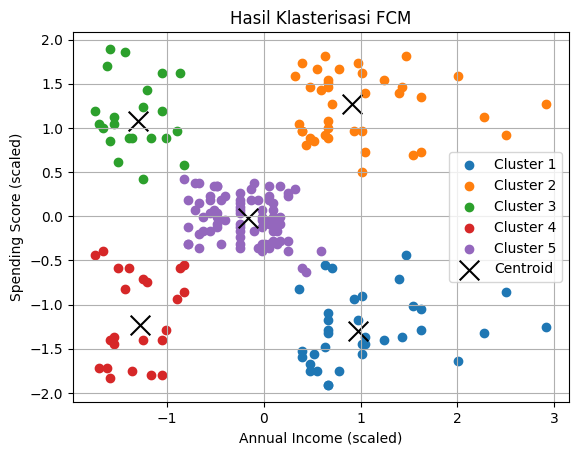

In [15]:
for i in range(5):
    plt.scatter(X_scaled[df['Cluster'] == i+1, 0], X_scaled[df['Cluster'] == i+1, 1], label=f'Cluster {i+1}')
plt.scatter(cntr[:, 0], cntr[:, 1], c='black', marker='x', s=200, label='Centroid')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.title('Hasil Klasterisasi FCM')
plt.legend()
plt.grid(True)

plt.show()

In [16]:
#eksperimen
#visualisasi derajat keanggotaan
pd.DataFrame(u.T[:10], columns=[f"Cluster {i+1}" for i in range(u.shape[0])])

,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5
0,0.056059,0.045922,0.184168,0.541829,0.172022
1,0.013389,0.025922,0.884817,0.029948,0.045925
2,0.046872,0.021890,0.043258,0.822109,0.065871
3,0.011420,0.021018,0.899062,0.027148,0.041352
4,0.056291,0.046674,0.190829,0.522297,0.183910
5,0.010077,0.018465,0.909796,0.024163,0.037499
6,0.043465,0.019677,0.038176,0.838309,0.060373
7,0.024909,0.059368,0.793564,0.045206,0.076952
8,0.054494,0.023567,0.043716,0.807684,0.070539
9,0.010753,0.018743,0.899895,0.027353,0.043256


In [17]:
#bandingkan dengan k-means
from sklearn.cluster import KMeans
km = KMeans(n_clusters=5, random_state=42)
df['KMeans_Cluster'] = km.fit_predict(X_scaled) + 1
df[['Cluster', 'KMeans_Cluster']].head(10)

,Cluster,KMeans_Cluster
0,4,5
1,3,3
2,4,5
3,3,3
4,4,5
5,3,3
6,4,5
7,3,3
8,4,5
9,3,3


In [18]:
#evaluasi silhouette score
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, np.argmax(u, axis=0))
print("Silhouette Score:", score)

Silhouette Score: 0.5546571631111091
